# Task 2 - Adaptive Threshold Parameter Study

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path('outputs')
OUT.mkdir(exist_ok=True)

In [2]:
img = cv2.imread("sudoku.png", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(
        "Place sudoku.png in the notebook folder."
    )

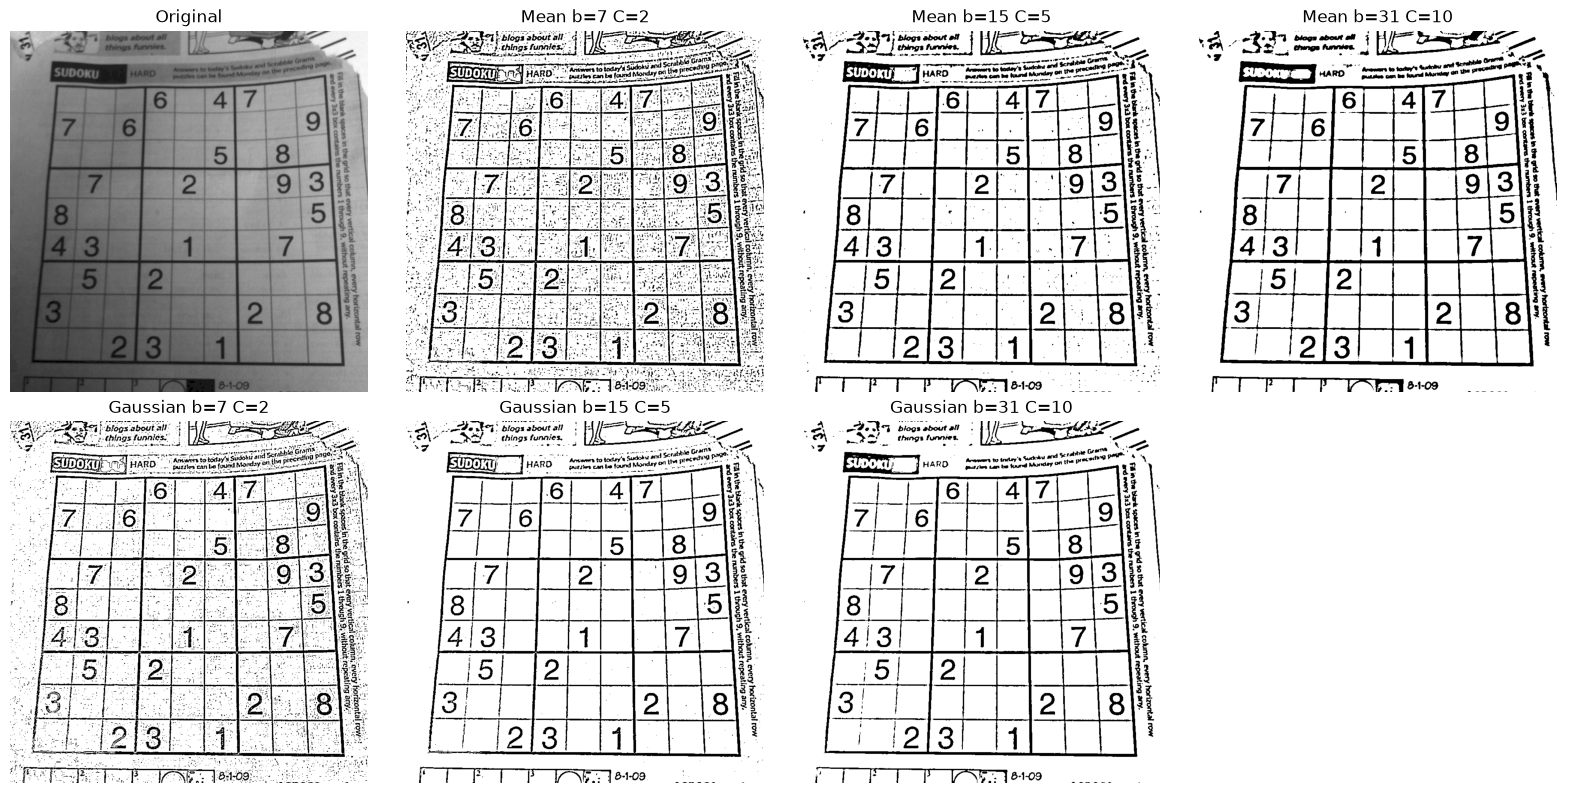

True

In [3]:
# Define different adaptive thresholding configurations
configs = [
    ("Mean", cv2.ADAPTIVE_THRESH_MEAN_C, 7, 2),
    ("Mean", cv2.ADAPTIVE_THRESH_MEAN_C, 15, 5),
    ("Mean", cv2.ADAPTIVE_THRESH_MEAN_C, 31, 10),
    ("Gaussian", cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 7, 2),
    ("Gaussian", cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 15, 5),
    ("Gaussian", cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 31, 10),
]

# Store the thresholded images
results = []

# Apply each adaptive thresholding configuration
for name, method, block, c in configs:
    thresholded = cv2.adaptiveThreshold(
        img,
        255,
        method,
        cv2.THRESH_BINARY,
        block,
        c
    )

    # Store the configuration name and resulting image
    results.append(
        (f"{name} b={block} C={c}", thresholded)
    )

# Create a 2x4 grid for displaying the results
fig, ax = plt.subplots(2, 4, figsize=(16, 8))

# Flatten the axes array for easier iteration
ax = ax.ravel()

# Display the original image
ax[0].imshow(img, cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

# Display all thresholding results
for a, (title, image) in zip(ax[1:], results):
    a.imshow(image, cmap="gray")
    a.set_title(title)
    a.axis("off")

# Hide the unused subplot
ax[-1].axis("off")

# Adjust layout and display the results
plt.tight_layout()
plt.show()

# Save the selected result (5th thresholded image)
cv2.imwrite(
    str(OUT / "task2_final.png"),
    results[4][1]
)


## Analysis
- Too small a neighbourhood follows tiny local variations and can increase noise or fragment strokes.
- Too large a neighbourhood becomes less local and can perform poorly across illumination gradients.
- Increasing `C` lowers the local threshold (`local statistic - C`) and changes how much foreground/background is retained.
- The six panels explicitly cover three block sizes, three C values, and both Mean and Gaussian methods. The selected final example is Gaussian, `blockSize=15`, `C=5`; judge the cleanest setting visually for the supplied image.